# Multimodal Food Recognition & Calorie Estimation
### Vision-Language Model: Qwen3-VL

**Task:** Given **either** a food **image**, **text alone** (e.g. *"chicken shawarma"* or *"I had a bowl of oatmeal for breakfast"*), **or both together**, predict:
- **Food name**
- **Calories** (per 100 g)
- **Fat** (per 100 g)

**Approach:** Fine-tune **Qwen3-VL-2B-Instruct** (a natively multimodal Vision-Language Model) with **LoRA**.
Unlike the original Qwen2-VL version of this notebook — which only ever saw `image + prompt → answer` during
training, and therefore could *only* work when given an image — this version builds a **mixed training set**:
some examples are `image + text → answer` and some are `text-only → answer` (the text names or describes the
food directly, e.g. *"What are the calories and fat in grilled salmon?"*). Training on both patterns teaches the
model to answer reliably whether the user sends a photo, just types the food name, or does both — all grounded in
the same structured nutrition lookup table built from `final_matched_dataset.csv`.

**Data:**
| Source | Content |
|---|---|
| `dataset (6).zip` | 18,120 food images across 64 classes (folder name = label) |
| `final_matched_dataset.csv` | 13,829 rows of food name → ingredients, category, calories, protein, fat, carb (per 100 g) |

**Notebook structure**
1. Setup & installs
2. Data preparation (images + nutrition CSV → unified manifest)
3. Building the per-class nutrition lookup table
4. Train / val / test split
5. Converting the manifest into **mixed** Qwen3-VL chat-style training examples (image+text **and** text-only)
6. Loading Qwen3-VL + LoRA configuration
7. Training
8. Inference pipeline (image **and/or** text → structured JSON output)
9. Evaluation (classification accuracy + calorie/fat MAE)
10. Demo


## 1. Setup & Installs
Run this once. Requires a GPU (fine-tuning) — a free Colab T4/A100 or better is enough for Qwen3-VL-2B with 4-bit LoRA.
Qwen3-VL needs a recent `transformers` build (>= 4.57.0) — it's a newer architecture than Qwen2-VL, so the older
pinned version from the original notebook won't recognize it.

In [1]:
# On Kaggle: Settings (top-right) -> Internet -> On, and Accelerator -> GPU T4 x2, BEFORE running this cell.
!pip install -q -U "transformers>=4.57.0" accelerate peft bitsandbytes qwen-vl-utils
print("Uncomment and run the pip install above the first time you run this notebook.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 83.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 50.5 MB/s eta 0:00:00:00:0100:01
Uncomment and run the pip install above the first time you run this notebook.


In [2]:
import os
import io
import json
import glob
import random
import difflib
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

random.seed(42)
np.random.seed(42)

# ----------------------------------------------------------------------------
# CONFIG — auto-detects Kaggle vs Colab/local, but you can always hardcode
# IMAGE_ROOT_DIR / NUTRITION_CSV_PATH yourself below if auto-detection picks
# the wrong folder (just print(IMAGE_ROOT_DIR) after running this cell to check).
# ----------------------------------------------------------------------------
ON_KAGGLE = os.path.isdir("/kaggle/input")
WORK_DIR = "/kaggle/working/food_vlm_work" if ON_KAGGLE else "food_vlm_work"
os.makedirs(WORK_DIR, exist_ok=True)


def find_image_root(base):
    """Walk `base` looking for a folder whose sub-folders are full of images
    (i.e. the food_class/image.jpg layout) — works regardless of how deeply
    Kaggle/Colab nested your uploaded dataset."""
    best_dir, best_score = None, 0
    for root, dirs, files in os.walk(base):
        score = 0
        for d in dirs:
            dpath = os.path.join(root, d)
            try:
                sample = os.listdir(dpath)[:20]
            except (OSError, PermissionError):
                continue
            if any(f.lower().endswith((".jpg", ".jpeg", ".png")) for f in sample):
                score += 1
        if score > best_score:
            best_dir, best_score = root, score
    return best_dir


def find_nutrition_csv(base):
    """Find the nutrition CSV anywhere under `base`, preferring a filename
    that contains 'match' (as in final_matched_dataset.csv)."""
    candidates = []
    for root, dirs, files in os.walk(base):
        for f in files:
            if f.lower().endswith(".csv"):
                candidates.append(os.path.join(root, f))
    if not candidates:
        return None
    matched = [c for c in candidates if "match" in os.path.basename(c).lower()]
    return matched[0] if matched else candidates[0]


if ON_KAGGLE:
    SEARCH_BASE = "/kaggle/input"
    IMAGE_ZIP_PATH = None  # Kaggle auto-extracts zipped datasets, so usually not needed
    EXTRACT_DIR = find_image_root(SEARCH_BASE)
    NUTRITION_CSV_PATH = find_nutrition_csv(SEARCH_BASE)

    # Fallback: if the zip was NOT auto-extracted, find_image_root will fail
    # (score stays 0) — in that case look for the .zip file itself instead.
    if EXTRACT_DIR is None:
        for root, dirs, files in os.walk(SEARCH_BASE):
            for f in files:
                if f.lower().endswith(".zip"):
                    IMAGE_ZIP_PATH = os.path.join(root, f)
        EXTRACT_DIR = os.path.join(WORK_DIR, "dataset")

else:
    # Colab / local: edit these two paths to match your uploaded filenames
    IMAGE_ZIP_PATH = "dataset (6).zip"
    NUTRITION_CSV_PATH = "final_matched_dataset.csv"
    EXTRACT_DIR = "dataset"

print("Running on Kaggle:", ON_KAGGLE)
print("IMAGE_ZIP_PATH     :", IMAGE_ZIP_PATH)
print("EXTRACT_DIR         :", EXTRACT_DIR)
print("NUTRITION_CSV_PATH  :", NUTRITION_CSV_PATH)
print("WORK_DIR            :", WORK_DIR)

assert NUTRITION_CSV_PATH is not None, "Could not auto-find the nutrition CSV — set NUTRITION_CSV_PATH manually."


Running on Kaggle: True
IMAGE_ZIP_PATH     : None
EXTRACT_DIR         : /kaggle/input/datasets/bassmalamahmoud/food-dataset/dataset (6)/dataset
NUTRITION_CSV_PATH  : /kaggle/input/datasets/bassmalamahmoud/food-dataset/final_matched_dataset (1) (2).csv
WORK_DIR            : /kaggle/working/food_vlm_work


## 2. Data Preparation
### 2.1 Extract the image dataset

In [3]:
if IMAGE_ZIP_PATH and not os.path.isdir(EXTRACT_DIR):
    with zipfile.ZipFile(IMAGE_ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR if ON_KAGGLE else ".")
    print("Extracted images to:", EXTRACT_DIR)
else:
    print("Using already-available images at:", EXTRACT_DIR)

class_dirs = sorted([d for d in os.listdir(EXTRACT_DIR)
                      if os.path.isdir(os.path.join(EXTRACT_DIR, d))])
print(f"Found {len(class_dirs)} food classes")
print(class_dirs)


Using already-available images at: /kaggle/input/datasets/bassmalamahmoud/food-dataset/dataset (6)/dataset
Found 64 food classes
['apple', 'bakery', 'banana', 'beef', 'bread', 'breakfast', 'broccoli', 'burger', 'burrito', 'butter', 'cake', 'carrot', 'cheese', 'chicken', 'chips', 'chocolate', 'coffee', 'cookies', 'corn', 'cream', 'cucumber', 'duck', 'falafel', 'fish', 'fried_chicken', 'garlic', 'grape', 'hummus', 'ice_cream', 'juice', 'kebab', 'lamb', 'lasagna', 'lettuce', 'mango', 'milk', 'noodles', 'oats', 'onion', 'orange', 'pasta', 'pineapple', 'pizza', 'popcorn', 'potato', 'quinoa', 'rice', 'salad', 'salmon', 'sandwich', 'shawarma', 'shrimp', 'smoothie', 'spinach', 'strawberry', 'sushi', 'sweet_potato', 'taco', 'tea', 'tomato', 'tuna', 'turkey', 'watermelon', 'yogurt']


In [4]:
if IMAGE_ZIP_PATH and not os.path.isdir(EXTRACT_DIR):
    with zipfile.ZipFile(IMAGE_ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_DIR if ON_KAGGLE else ".")
    print("Extracted images to:", EXTRACT_DIR)
else:
    print("Using already-available images at:", EXTRACT_DIR)

class_dirs = sorted([d for d in os.listdir(EXTRACT_DIR)
                      if os.path.isdir(os.path.join(EXTRACT_DIR, d))])
print(f"Found {len(class_dirs)} food classes")
print(class_dirs)


Using already-available images at: /kaggle/input/datasets/bassmalamahmoud/food-dataset/dataset (6)/dataset
Found 64 food classes
['apple', 'bakery', 'banana', 'beef', 'bread', 'breakfast', 'broccoli', 'burger', 'burrito', 'butter', 'cake', 'carrot', 'cheese', 'chicken', 'chips', 'chocolate', 'coffee', 'cookies', 'corn', 'cream', 'cucumber', 'duck', 'falafel', 'fish', 'fried_chicken', 'garlic', 'grape', 'hummus', 'ice_cream', 'juice', 'kebab', 'lamb', 'lasagna', 'lettuce', 'mango', 'milk', 'noodles', 'oats', 'onion', 'orange', 'pasta', 'pineapple', 'pizza', 'popcorn', 'potato', 'quinoa', 'rice', 'salad', 'salmon', 'sandwich', 'shawarma', 'shrimp', 'smoothie', 'spinach', 'strawberry', 'sushi', 'sweet_potato', 'taco', 'tea', 'tomato', 'tuna', 'turkey', 'watermelon', 'yogurt']


In [5]:
# Build an image manifest: image_path, label
records = []
for cls in class_dirs:
    for fp in glob.glob(os.path.join(EXTRACT_DIR, cls, "*")):
        if fp.lower().endswith((".jpg", ".jpeg", ".png")):
            records.append({"image_path": fp, "label": cls})

images_df = pd.DataFrame(records)
print("Total images:", len(images_df))
print("Images per class:")
print(images_df["label"].value_counts().sort_index())


Total images: 18120
Images per class:
label
apple         300
bakery         30
banana        300
beef          300
bread         300
             ... 
tomato        300
tuna          300
turkey        300
watermelon    300
yogurt        300
Name: count, Length: 64, dtype: int64


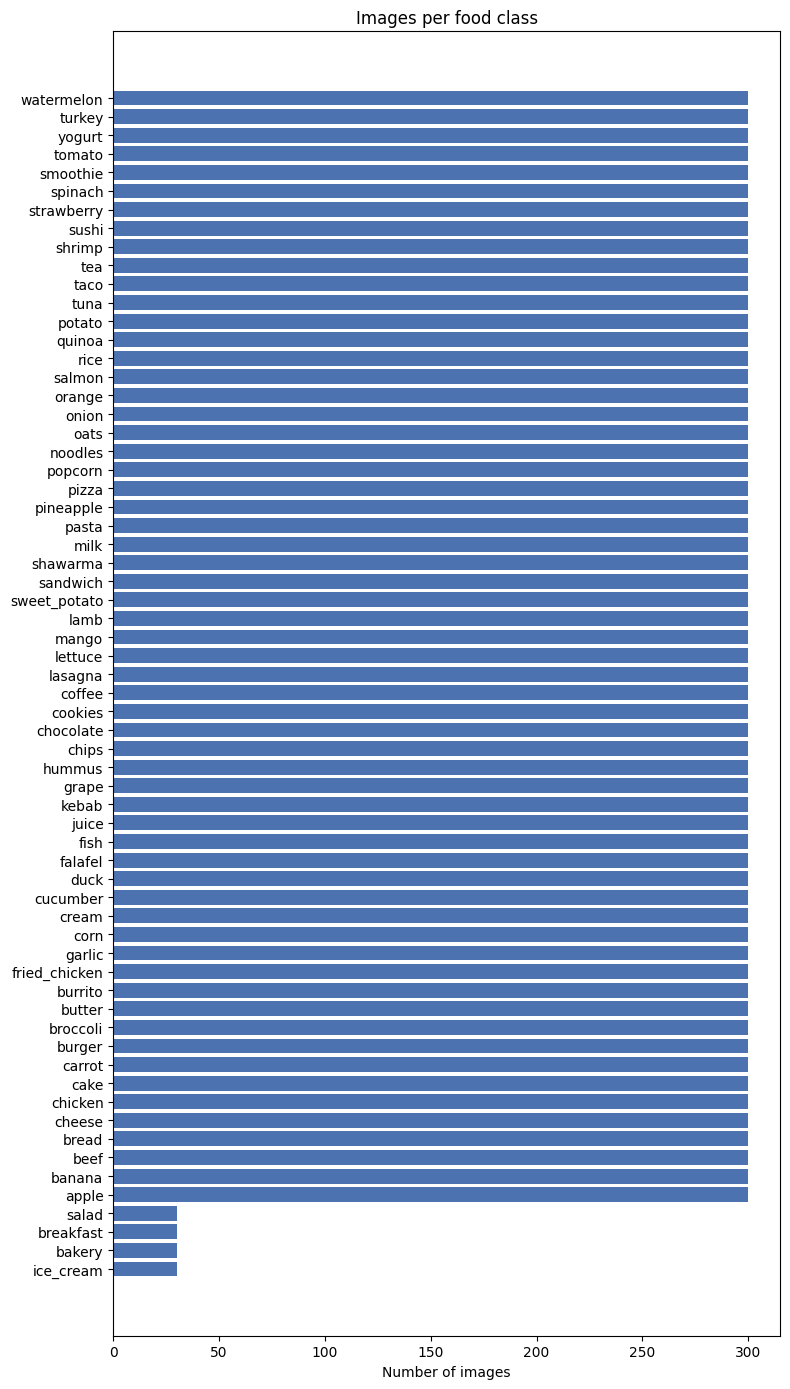

In [6]:
# Visualize class balance
counts = images_df["label"].value_counts().sort_values()
plt.figure(figsize=(8, 14))
plt.barh(counts.index, counts.values, color="#4C72B0")
plt.xlabel("Number of images")
plt.title("Images per food class")
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, "class_distribution.png"), dpi=110)
plt.show()


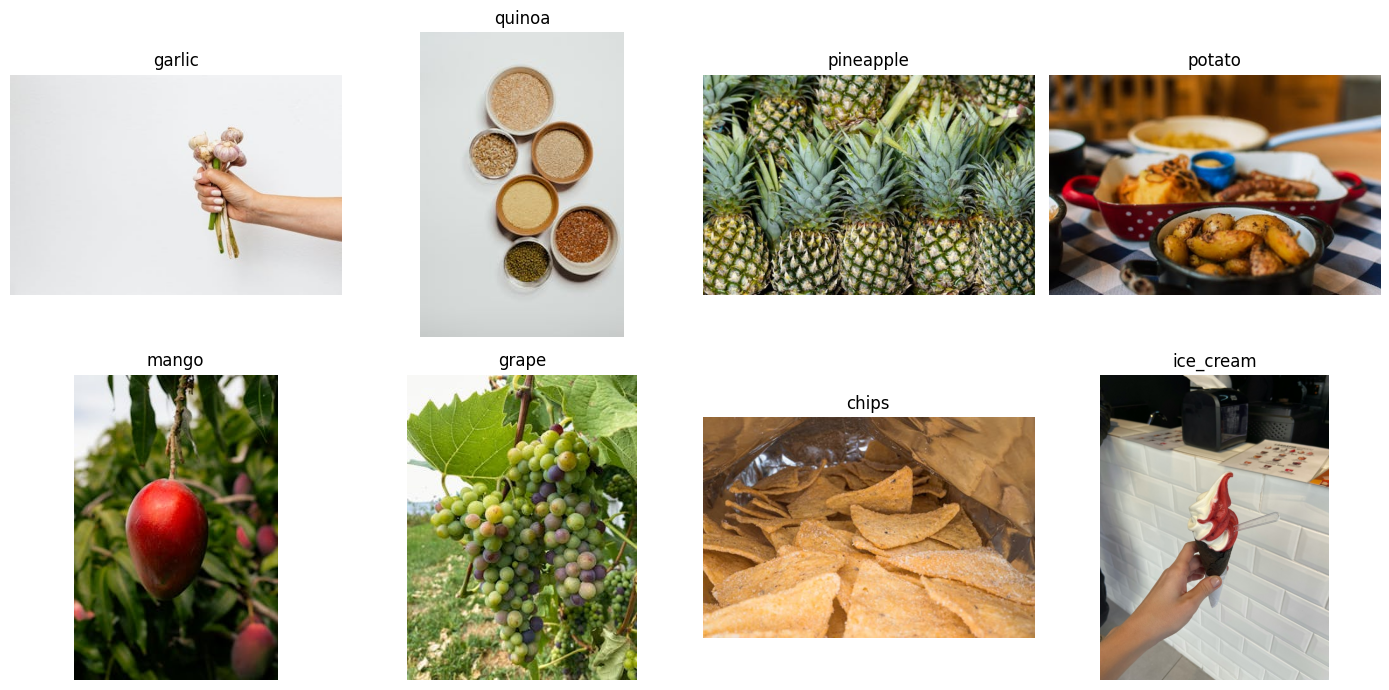

In [10]:
# Peek at a few sample images
sample_classes = random.sample(class_dirs, 8)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, cls in zip(axes.flat, sample_classes):
    fp = images_df[images_df.label == cls].iloc[0].image_path
    img = Image.open(fp).convert("RGB")
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")
plt.tight_layout()
plt.show()


### 2.2 Load & explore the nutrition (text) data

In [17]:
nutrition_df = pd.read_csv(NUTRITION_CSV_PATH)
print(nutrition_df.shape)
print(nutrition_df.dtypes)
nutrition_df.head()


(13829, 9)
name             object
matched_name     object
ingredients      object
category         object
portion          object
calories        float64
protein         float64
fat             float64
carb            float64
dtype: object


,name,matched_name,ingredients,category,portion,calories,protein,fat,carb
0,chicken handi,chicken,"Chicken, Onion, Tomatoes, Garlic, Ginger paste...",meat,100 g,166.0,21.4,1.79,0.0
1,chicken mandi,chicken,"Chicken, Basmati Rice, Water, Onion, Garlic, G...",meat,100 g,166.0,21.4,1.79,0.0
2,sticky chicken,chicken,"Chicken drumsticks, Soy Sauce, Honey, Olive Oi...",meat,100 g,166.0,21.4,1.79,0.0
3,chicken congee,chicken,"Chicken, Salt, Pepper, Ginger Cordial, Ginger,...",meat,100 g,166.0,21.4,1.79,0.0
4,chicken karaage,chicken,"Chicken, Ginger, Garlic, Soy sauce, Sake, Gran...",meat,100 g,166.0,21.4,1.79,0.0


In [18]:
# Normalize text columns
nutrition_df["name"] = nutrition_df["name"].astype(str).str.lower().str.strip()
nutrition_df["matched_name"] = nutrition_df["matched_name"].astype(str).str.lower().str.strip()

print("Unique matched_name values:", nutrition_df["matched_name"].nunique())
print("Unique categories:", nutrition_df["category"].nunique())
nutrition_df[["calories", "protein", "fat", "carb"]].describe()


Unique matched_name values: 1278
Unique categories: 34


,calories,protein,fat,carb
count,13829.000000,13829.000000,13829.000000,13829.000000
mean,206.839395,9.035977,10.275180,21.828936
std,164.020339,7.567167,13.137428,22.566389
min,0.000000,0.000000,0.000000,0.000000
25%,76.000000,2.940000,1.790000,3.800000
50%,173.000000,7.000000,5.880000,13.300000
75%,308.000000,14.110000,14.090000,35.700000
max,929.000000,75.200000,100.000000,100.000000


## 3. Building the Per-Class Nutrition Lookup Table

The image folders use 64 broad class names (e.g. `pizza`, `ice_cream`, `fried_chicken`), while the nutrition CSV
is far more fine-grained (1,278 unique `matched_name` values, e.g. *"chicken salad"*, *"grilled chicken salad"*).

To connect the two, for each of the 64 image classes we look for nutrition rows in this order of preference:
1. **Exact match** on `matched_name` (e.g. `apple` → `matched_name == "apple"`)
2. **Substring match** on the raw `name` column (e.g. `bread` matches any row whose `name` contains "bread")
3. **Fuzzy match** on `matched_name` using `difflib` (catches small spelling differences)

We then average `calories`, `protein`, `fat`, `carb` across every matching row to get one nutrition profile per class.
This lookup table is what grounds the VLM's answers — the model is taught to report *these* numbers for each class.


In [19]:
def build_nutrition_lookup(classes, df):
    grp = df.groupby("matched_name")[["calories", "protein", "fat", "carb"]].mean()
    all_matched_names = grp.index.tolist()

    lookup = {}
    match_report = []

    for cls in classes:
        key = cls.replace("_", " ").lower().strip()

        if key in grp.index:
            vals = grp.loc[key].to_dict()
            method = "exact_match"
            matched_on = key

        else:
            sub = df[df["name"].str.contains(key, na=False, regex=False)]
            if len(sub) > 0:
                vals = sub[["calories", "protein", "fat", "carb"]].mean().to_dict()
                method = f"substring_match (n={len(sub)})"
                matched_on = key
            else:
                close = difflib.get_close_matches(key, all_matched_names, n=1, cutoff=0.75)
                if close:
                    vals = grp.loc[close[0]].to_dict()
                    method = "fuzzy_match"
                    matched_on = close[0]
                else:
                    vals = {"calories": np.nan, "protein": np.nan, "fat": np.nan, "carb": np.nan}
                    method = "MISSING"
                    matched_on = None

        lookup[cls] = {
            "food_name": cls.replace("_", " "),
            "calories_per_100g": round(vals["calories"], 1) if pd.notna(vals["calories"]) else None,
            "protein_per_100g": round(vals["protein"], 1) if pd.notna(vals["protein"]) else None,
            "fat_per_100g": round(vals["fat"], 1) if pd.notna(vals["fat"]) else None,
            "carb_per_100g": round(vals["carb"], 1) if pd.notna(vals["carb"]) else None,
        }
        match_report.append({"class": cls, "method": method, "matched_on": matched_on})

    return lookup, pd.DataFrame(match_report)


nutrition_lookup, match_report_df = build_nutrition_lookup(class_dirs, nutrition_df)

missing = match_report_df[match_report_df.method == "MISSING"]
print(f"Classes with no nutrition match: {len(missing)}")
match_report_df


Classes with no nutrition match: 0


,class,method,matched_on
0,apple,exact_match,apple
1,bakery,substring_match (n=1),bakery
2,banana,exact_match,banana
3,beef,exact_match,beef
4,bread,substring_match (n=397),bread
...,...,...,...
59,tomato,exact_match,tomato
60,tuna,exact_match,tuna
61,turkey,exact_match,turkey
62,watermelon,substring_match (n=50),watermelon


In [20]:
# Save the lookup table for use at inference time and during dataset construction
with open(os.path.join(WORK_DIR, "class_nutrition_lookup.json"), "w") as f:
    json.dump(nutrition_lookup, f, indent=2)

nutrition_table_df = pd.DataFrame(nutrition_lookup).T
nutrition_table_df.index.name = "class"
nutrition_table_df.to_csv(os.path.join(WORK_DIR, "class_nutrition_lookup.csv"))
nutrition_table_df


,food_name,calories_per_100g,protein_per_100g,fat_per_100g,carb_per_100g
class,,,,,
apple,apple,64.0,0.0,0.0,11.7
bakery,bakery,355.0,3.5,23.5,56.5
banana,banana,92.0,12.5,6.2,40.6
beef,beef,156.0,20.0,5.9,0.0
bread,bread,248.8,9.2,9.8,32.4
...,...,...,...,...,...
tomato,tomato,20.0,14.3,0.0,35.7
tuna,tuna,126.0,5.7,3.8,10.4
turkey,turkey,157.0,9.8,1.3,6.8


## 4. Unified Manifest: image + label + nutrition facts

In [21]:
def attach_nutrition(row):
    info = nutrition_lookup[row["label"]]
    return pd.Series({
        "food_name": info["food_name"],
        "calories": info["calories_per_100g"],
        "protein": info["protein_per_100g"],
        "fat": info["fat_per_100g"],
        "carb": info["carb_per_100g"],
    })

full_df = images_df.join(images_df.apply(attach_nutrition, axis=1))
full_df.to_csv(os.path.join(WORK_DIR, "full_manifest.csv"), index=False)
print(full_df.shape)
full_df.head()


(18120, 7)


,image_path,label,food_name,calories,protein,fat,carb
0,/kaggle/input/datasets/bassmalamahmoud/food-da...,apple,apple,64.0,0.0,0.0,11.7
1,/kaggle/input/datasets/bassmalamahmoud/food-da...,apple,apple,64.0,0.0,0.0,11.7
2,/kaggle/input/datasets/bassmalamahmoud/food-da...,apple,apple,64.0,0.0,0.0,11.7
3,/kaggle/input/datasets/bassmalamahmoud/food-da...,apple,apple,64.0,0.0,0.0,11.7
4,/kaggle/input/datasets/bassmalamahmoud/food-da...,apple,apple,64.0,0.0,0.0,11.7


### 4.1 Train / Val / Test split

We stratify by `label` so every class is represented in all three splits. For fast experimentation you can cap the
number of images per class with `MAX_PER_CLASS` (the four smallest classes only have 30 images, so 30 is the
effective ceiling if you want balanced classes — set to `None` to use the full 18,120 images).

In [22]:
MAX_PER_CLASS = 40  # set to None to use every image

if MAX_PER_CLASS is not None:
    sampled_parts = [
        g.sample(min(len(g), MAX_PER_CLASS), random_state=42)
        for _, g in full_df.groupby("label")
    ]
    full_df = pd.concat(sampled_parts, ignore_index=True)

train_df, temp_df = train_test_split(full_df, test_size=0.2, stratify=full_df["label"], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42)

print("Train:", len(train_df), " Val:", len(val_df), " Test:", len(test_df))

train_df.to_csv(os.path.join(WORK_DIR, "train.csv"), index=False)
val_df.to_csv(os.path.join(WORK_DIR, "val.csv"), index=False)
test_df.to_csv(os.path.join(WORK_DIR, "test.csv"), index=False)


Train: 2016  Val: 252  Test: 252


## 5. Converting the Manifest into **Mixed** Qwen3-VL Training Examples

Qwen3-VL is trained on **chat-style conversations**. To get a model that works with **image, text, or both**,
we build **two kinds** of training examples from the same manifest and mix them together:

1. **Image + text** — a `user` turn with an image and a question (`"What is this and how many calories/fat does it have?"`),
   exactly like the original notebook.
2. **Text only** — a `user` turn with *no image*, where the question itself names or describes the food
   (`"What are the calories and fat in grilled salmon?"`), and the same structured answer as the target.

`TEXT_ONLY_FRACTION` controls what share of training examples are text-only vs image(+text). Because both example
types are drawn from the *same* underlying rows (same foods, same nutrition numbers), the model learns a single
consistent mapping from "food identity" (however it's provided) to nutrition facts — it just learns to get that
identity from an image in one case and from text in the other.


In [23]:
QUESTION_TEMPLATES_IMAGE = [
    "What food is this and how many calories and how much fat does it have?",
    "Identify this dish and estimate its calories and fat content.",
    "Can you tell me what this food is, along with its calories and fat per 100g?",
    "What is this, and what are its nutrition facts (calories, fat)?",
]

# Text-only templates MUST name/describe the food directly (no image will be given),
# so the model can only answer correctly by reading the food name out of the text itself.
QUESTION_TEMPLATES_TEXT = [
    "What are the calories and fat in {food_name}?",
    "I just had {food_name}. How many calories and how much fat is that, per 100g?",
    "Tell me the calories and fat content of {food_name}.",
    "Can you give me the nutrition facts (calories, fat) for {food_name}?",
    "How many calories and how much fat does {food_name} have per 100 grams?",
]

ANSWER_TEMPLATE = (
    "Food: {food_name}\n"
    "Calories: {calories} kcal per 100g\n"
    "Fat: {fat} g per 100g"
)

# Fraction of training examples that are TEXT-ONLY (no image) vs image(+text).
# 0.3 means ~30% of examples teach the "text alone -> nutrition" pattern, ~70% keep
# the original "image (+ text) -> nutrition" pattern. Tune this if you want the model
# to lean more heavily toward one input mode or the other.
TEXT_ONLY_FRACTION = 0.3


def make_conversation(row, force_mode=None):
    """Builds one training example.

    force_mode: None -> randomly choose per TEXT_ONLY_FRACTION,
                "text" -> force a text-only example,
                "image" -> force an image(+text) example.
    Returns a dict with an "image" key (path, or None for text-only examples) and
    a "conversations" key in Qwen3-VL chat format.
    """
    mode = force_mode or ("text" if random.random() < TEXT_ONLY_FRACTION else "image")

    answer = ANSWER_TEMPLATE.format(
        food_name=row["food_name"],
        calories=row["calories"],
        fat=row["fat"],
    )

    if mode == "text":
        question = random.choice(QUESTION_TEMPLATES_TEXT).format(food_name=row["food_name"])
        user_content = [{"type": "text", "text": question}]
        image_path = None
    else:
        question = random.choice(QUESTION_TEMPLATES_IMAGE)
        user_content = [
            {"type": "image", "image": row["image_path"]},
            {"type": "text", "text": question},
        ]
        image_path = row["image_path"]

    return {
        "image": image_path,  # None for text-only examples
        "conversations": [
            {"role": "user", "content": user_content},
            {"role": "assistant", "content": [{"type": "text", "text": answer}]},
        ],
    }


def build_jsonl(df, out_path, duplicate_for_text_only=True):
    """Writes one JSONL example per row by default. If duplicate_for_text_only=True,
    ALSO writes a second, text-only example per row (rather than replacing the image
    example with a coin-flip) - this guarantees every food gets both an image example
    and a text-only example somewhere in the data, instead of leaving it to chance.
    """
    with open(out_path, "w") as f:
        for _, row in df.iterrows():
            if duplicate_for_text_only:
                f.write(json.dumps(make_conversation(row, force_mode="image")) + "\n")
                f.write(json.dumps(make_conversation(row, force_mode="text")) + "\n")
            else:
                f.write(json.dumps(make_conversation(row)) + "\n")


build_jsonl(train_df, os.path.join(WORK_DIR, "train.jsonl"))
build_jsonl(val_df, os.path.join(WORK_DIR, "val.jsonl"))
build_jsonl(test_df, os.path.join(WORK_DIR, "test.jsonl"))

# Preview one image example and one text-only example
with open(os.path.join(WORK_DIR, "train.jsonl")) as f:
    image_example = json.loads(f.readline())
    text_example = json.loads(f.readline())
print("--- image(+text) example ---")
print(json.dumps(image_example, indent=2))
print("\n--- text-only example ---")
print(json.dumps(text_example, indent=2))


--- image(+text) example ---
{
  "image": "/kaggle/input/datasets/bassmalamahmoud/food-dataset/dataset (6)/dataset/falafel/falafel_161.jpg",
  "conversations": [
    {
      "role": "user",
      "content": [
        {
          "type": "image",
          "image": "/kaggle/input/datasets/bassmalamahmoud/food-dataset/dataset (6)/dataset/falafel/falafel_161.jpg"
        },
        {
          "type": "text",
          "text": "Can you tell me what this food is, along with its calories and fat per 100g?"
        }
      ]
    },
    {
      "role": "assistant",
      "content": [
        {
          "type": "text",
          "text": "Food: falafel\nCalories: 350.0 kcal per 100g\nFat: 41.2 g per 100g"
        }
      ]
    }
  ]
}

--- text-only example ---
{
  "image": null,
  "conversations": [
    {
      "role": "user",
      "content": [
        {
          "type": "text",
          "text": "What are the calories and fat in falafel?"
        }
      ]
    },
    {
      "role": "assis

## 6. Load Qwen3-VL + Configure LoRA

We use **Qwen/Qwen3-VL-2B-Instruct** (small enough to fine-tune on a single consumer/Colab GPU with 4-bit
quantization). Swap in `Qwen/Qwen3-VL-4B-Instruct` or larger for higher accuracy if you have more GPU memory.
Qwen3-VL is natively multimodal (it handles image+text and text-only inputs out of the box) — our LoRA training
just needs to see **both** patterns in its data (Part 5) so the fine-tuned adapter keeps that flexibility instead
of narrowing down to "image only", which is what happened in the original Qwen2-VL version of this notebook.

We freeze the base model weights and train small **LoRA adapters** on the attention + MLP projection layers —
this is fast, memory-cheap, and works well for teaching the model a new *response format* + a fixed set of
food/nutrition facts, without needing to update billions of parameters.


In [24]:
import torch
from transformers import (
    Qwen3VLForConditionalGeneration,
    AutoProcessor,
    BitsAndBytesConfig,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from qwen_vl_utils import process_vision_info

MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,  # T4-friendly dtype
    bnb_4bit_use_double_quant=True,
)

processor = AutoProcessor.from_pretrained(MODEL_ID, min_pixels=256 * 28 * 28, max_pixels=768 * 28 * 28)

model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,  # T4-friendly dtype
    device_map="auto",
)

model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

trainable params: 17,432,576 || all params: 2,144,964,608 || trainable%: 0.8127


## 7. PyTorch Dataset & Collator

The collator has to handle **mixed batches**: some examples carry an image, some don't (`example["image"] is None`
for the text-only ones from Part 5). Qwen3-VL's processor is fine with this as long as we only pass images for the
examples that actually have one — a text-only example's chat text simply has no `<image>` placeholder, so we must
NOT feed it an image, or the placeholder count and image count would mismatch.


In [25]:
import json
from torch.utils.data import Dataset

class FoodVLMDataset(Dataset):
    """Reads a JSONL file of {image, conversations} examples built in Part 5.
    `image` is a file path for image(+text) examples, or None for text-only examples."""

    def __init__(self, jsonl_path):
        with open(jsonl_path) as f:
            self.examples = [json.loads(line) for line in f]

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        return self.examples[idx]


# Qwen3-VL uses a ChatML-style template; the assistant's answer always starts
# right after this marker. We use it to mask everything BEFORE the answer
# (system prompt, user question, and all the image tokens) so the loss is
# only computed on the actual answer text - otherwise the huge number of
# repetitive image/prompt tokens drowns out the learning signal and the loss
# never moves.
ASSISTANT_MARKER_IDS = processor.tokenizer(
    "<|im_start|>assistant\n", add_special_tokens=False
)["input_ids"]


def _find_assistant_start(token_ids, marker=ASSISTANT_MARKER_IDS):
    n, m = len(token_ids), len(marker)
    for i in range(n - m + 1):
        if token_ids[i:i + m] == marker:
            return i + m
    return None  # marker not found - fall back to masking the whole sequence


def collate_fn(batch, processor=processor):
    texts = [
        processor.apply_chat_template(ex["conversations"], tokenize=False, add_generation_prompt=False)
        for ex in batch
    ]

    # Only pull vision inputs for examples that actually HAVE an image (mode == "image").
    # process_vision_info on a text-only conversation returns None/empty, since there's no
    # {"type": "image", ...} block to find - so we simply skip those examples here, rather
    # than passing an empty/None placeholder into the flat image list below.
    per_example_images = []
    for ex in batch:
        if ex.get("image"):
            imgs, _ = process_vision_info(ex["conversations"])
            per_example_images.append(imgs)
        else:
            per_example_images.append(None)

    # Qwen's processor expects a single FLAT list of images, in the same left-to-right
    # order as the <image> placeholders appear across `texts`. Text-only examples simply
    # contribute zero images to this flat list - they still get a text entry in `texts`,
    # they just don't have a corresponding image.
    flat_images = [img for imgs in per_example_images if imgs for img in imgs]
    images_arg = flat_images if len(flat_images) > 0 else None

    model_inputs = processor(
        text=texts,
        images=images_arg,
        padding=True,
        return_tensors="pt",
    )

    input_ids = model_inputs["input_ids"]
    labels = input_ids.clone()

    for i in range(input_ids.size(0)):
        seq = input_ids[i].tolist()
        start = _find_assistant_start(seq)
        if start is None:
            labels[i, :] = -100
        else:
            labels[i, :start] = -100

    # also mask padding tokens everywhere
    labels[input_ids == processor.tokenizer.pad_token_id] = -100

    model_inputs["labels"] = labels
    return model_inputs


train_dataset = FoodVLMDataset(os.path.join(WORK_DIR, "train.jsonl"))
val_dataset = FoodVLMDataset(os.path.join(WORK_DIR, "val.jsonl"))
n_text_only = sum(1 for ex in train_dataset.examples if not ex.get("image"))
print(f"Train examples: {len(train_dataset)}  (text-only: {n_text_only}, image+text: {len(train_dataset) - n_text_only})")
print(f"Val examples: {len(val_dataset)}")


Train examples: 4032  (text-only: 2016, image+text: 2016)
Val examples: 504


## 8. Fine-tune with LoRA

In [26]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir=os.path.join(WORK_DIR, "qwen3vl_food_lora"),
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=3,
    learning_rate=1e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    fp16=True,  # T4 has no native bf16 support; fp16 is much faster on T4
    gradient_checkpointing=True,
    report_to="none",
    remove_unused_columns=False,  # keep raw dict fields (image/conversations) for our custom collate_fn
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate_fn,
)

trainer.train()


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch,Training Loss,Validation Loss
1,0.005558,0.006058
2,0.004554,0.005132
3,0.005120,0.004570


TrainOutput(global_step=756, training_loss=0.05909612783718677, metrics={'train_runtime': 6216.3663, 'train_samples_per_second': 1.946, 'train_steps_per_second': 0.122, 'total_flos': 3.2009980963405824e+16, 'train_loss': 0.05909612783718677, 'epoch': 3.0})

In [27]:
# Save the LoRA adapter (small - a few hundred MB, not a full copy of the base model)
ADAPTER_DIR = os.path.join(WORK_DIR, "qwen3vl_food_lora_adapter")
model.save_pretrained(ADAPTER_DIR)
processor.save_pretrained(ADAPTER_DIR)
print("Saved adapter to:", ADAPTER_DIR)


Saved adapter to: /kaggle/working/food_vlm_work/qwen3vl_food_lora_adapter


## 9. Inference Pipeline

Given **an image, a text description, or both**, we:
1. Run the fine-tuned Qwen3-VL model to get a natural-language answer.
2. Parse the answer into a structured `{food_name, calories, fat}` dict with a regex.
3. **Fall back** to the nutrition lookup table from Part 1 if the model's free-text numbers are missing/malformed —
   this keeps the final output grounded and reliable even if generation drifts.

`predict()` below now accepts `image_path=None` — pass just a `question`/description (e.g. `"grilled salmon"`)
for a text-only prediction, an image path alone for the original image-only behavior, or both together.


In [28]:
!pip install -q -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.6 MB/s eta 0:00:00a 0:00:01


In [29]:
import sys
for mod in list(sys.modules):
    if mod.startswith("torchao") or mod.startswith("peft"):
        del sys.modules[mod]

In [30]:
import re

def load_finetuned_model(adapter_dir=None, base_model_id="Qwen/Qwen3-VL-2B-Instruct"):
    """Load base model (+ optional LoRA adapter) for inference."""
    proc = AutoProcessor.from_pretrained(adapter_dir or base_model_id)
    base = Qwen3VLForConditionalGeneration.from_pretrained(
        base_model_id, torch_dtype=torch.bfloat16, device_map="auto"
    )
    if adapter_dir:
        from peft import PeftModel
        base = PeftModel.from_pretrained(base, adapter_dir)
    base.eval()
    return base, proc


def parse_food_answer(text):
    """Extract food name, calories, fat from a free-text model answer."""
    food_match = re.search(r"Food:\s*(.+)", text)
    cal_match = re.search(r"Calories:\s*([\d.]+)", text)
    fat_match = re.search(r"Fat:\s*([\d.]+)", text)

    return {
        "food_name": food_match.group(1).strip() if food_match else None,
        "calories": float(cal_match.group(1)) if cal_match else None,
        "fat": float(fat_match.group(1)) if fat_match else None,
    }


def predict(image_path=None, question=None, model=model, processor=processor, nutrition_lookup=nutrition_lookup):
    """Run a prediction from an image, text, or both.

    - image_path + question       -> original image(+text) behavior
    - image_path only             -> image with a default question
    - question only (no image)    -> text-only prediction (question should name/describe the food,
                                      e.g. "chicken shawarma" or "What are the calories in grilled salmon?")
    At least one of image_path / question must be provided.
    """
    if image_path is None and not question:
        raise ValueError("Provide an image_path, a question/food description, or both.")

    if image_path is not None:
        question = question or "What food is this and how many calories and how much fat does it have?"
        user_content = [
            {"type": "image", "image": image_path},
            {"type": "text", "text": question},
        ]
    else:
        # Text-only path: the question IS the food description (this is what the
        # text-only training examples from Part 5 taught the model to expect).
        user_content = [{"type": "text", "text": question}]

    conversation = [{"role": "user", "content": user_content}]

    text_prompt = processor.apply_chat_template(conversation, tokenize=False, add_generation_prompt=True)

    if image_path is not None:
        image_inputs, _ = process_vision_info(conversation)
        inputs = processor(text=[text_prompt], images=image_inputs, padding=True, return_tensors="pt").to(model.device)
    else:
        inputs = processor(text=[text_prompt], padding=True, return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=128, do_sample=False)

    generated = processor.batch_decode(
        output_ids[:, inputs["input_ids"].shape[1]:], skip_special_tokens=True
    )[0]

    parsed = parse_food_answer(generated)

    # Ground the numbers using the nutrition lookup table if the model's free-text values look off/missing.
    if parsed["food_name"]:
        key = parsed["food_name"].lower().strip().replace(" ", "_")
        if key in nutrition_lookup:
            if parsed["calories"] is None:
                parsed["calories"] = nutrition_lookup[key]["calories_per_100g"]
            if parsed["fat"] is None:
                parsed["fat"] = nutrition_lookup[key]["fat_per_100g"]

    parsed["raw_model_output"] = generated
    return parsed


In [31]:
!find /kaggle/working -iname "*adapter*"

/kaggle/working/food_vlm_work/qwen3vl_food_lora/checkpoint-252/adapter_config.json
/kaggle/working/food_vlm_work/qwen3vl_food_lora/checkpoint-252/adapter_model.safetensors
/kaggle/working/food_vlm_work/qwen3vl_food_lora/checkpoint-504/adapter_config.json
/kaggle/working/food_vlm_work/qwen3vl_food_lora/checkpoint-504/adapter_model.safetensors
/kaggle/working/food_vlm_work/qwen3vl_food_lora/checkpoint-756/adapter_config.json
/kaggle/working/food_vlm_work/qwen3vl_food_lora/checkpoint-756/adapter_model.safetensors
/kaggle/working/food_vlm_work/qwen3vl_food_lora_adapter
/kaggle/working/food_vlm_work/qwen3vl_food_lora_adapter/adapter_config.json
/kaggle/working/food_vlm_work/qwen3vl_food_lora_adapter/adapter_model.safetensors


In [32]:
# Example usage (run after training, or after loading a saved adapter):
model, processor = load_finetuned_model(ADAPTER_DIR)

# Image + text
result_image = predict(image_path=test_df.iloc[0]["image_path"], question="What is this food and what are its calories and fat?")
print("Image input:")
print(json.dumps(result_image, indent=2))

# Text only (no image) - question names the food directly
result_text = predict(question="What are the calories and fat in grilled salmon?")
print("\nText-only input:")
print(json.dumps(result_text, indent=2))


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


Image input:
{
  "food_name": "beef",
  "calories": 156.0,
  "fat": 5.9,
  "raw_model_output": "Food: beef\nCalories: 156.0 kcal per 100g\nFat: 5.9 g per 100g"
}

Text-only input:
{
  "food_name": "salmon",
  "calories": 180.0,
  "fat": 8.0,
  "raw_model_output": "Food: salmon\nCalories: 180.0 kcal per 100g\nFat: 8.0 g per 100g"
}


In [33]:
import peft.tuners.lora.torchao as _torchao_dispatch
_torchao_dispatch.dispatch_torchao = lambda *args, **kwargs: None

ADAPTER_DIR = "/kaggle/working/food_vlm_work/qwen3vl_food_lora_adapter"

model, processor = load_finetuned_model(ADAPTER_DIR)
result_image = predict(image_path=test_df.iloc[0]["image_path"], question="What is this food and what are its calories and fat?")
print("Image input:")
print(json.dumps(result_image, indent=2))

result_text = predict(question="What are the calories and fat in grilled salmon?")
print("\nText-only input:")
print(json.dumps(result_text, indent=2))


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

Image input:
{
  "food_name": "beef",
  "calories": 156.0,
  "fat": 5.9,
  "raw_model_output": "Food: beef\nCalories: 156.0 kcal per 100g\nFat: 5.9 g per 100g"
}

Text-only input:
{
  "food_name": "salmon",
  "calories": 180.0,
  "fat": 8.0,
  "raw_model_output": "Food: salmon\nCalories: 180.0 kcal per 100g\nFat: 8.0 g per 100g"
}


In [34]:
import shutil
shutil.make_archive("/kaggle/working/qwen3vl_food_lora_adapter", "zip", "/kaggle/working/food_vlm_work/qwen3vl_food_lora_adapter")


'/kaggle/working/qwen3vl_food_lora_adapter.zip'

In [35]:
ADAPTER_LOCAL_DIR = "/kaggle/working/food_vlm_work/qwen3vl_food_lora_adapter"

## 10. Evaluation

We evaluate on the held-out `test.csv` split from Part 1:
- **Classification accuracy** — does the predicted food name match the true label (fuzzy match, since the model
  answers in natural language, e.g. "fried chicken" vs "fried_chicken")?
- **Calorie / fat MAE (Mean Absolute Error)** — how close are the predicted numeric values to the ground-truth
  nutrition-lookup values for the true class?


In [36]:
from difflib import SequenceMatcher

def name_matches(pred_name, true_label, threshold=0.6):
    if not pred_name:
        return False
    a = pred_name.lower().replace("_", " ").strip()
    b = true_label.lower().replace("_", " ").strip()
    return SequenceMatcher(None, a, b).ratio() >= threshold or a in b or b in a


def evaluate(test_df, model=model, processor=processor, nutrition_lookup=nutrition_lookup):
    results = []
    for _, row in test_df.iterrows():
        pred = predict(row["image_path"], model=model, processor=processor, nutrition_lookup=nutrition_lookup)
        results.append({
            "image_path": row["image_path"],
            "true_label": row["label"],
            "true_calories": row["calories"],
            "true_fat": row["fat"],
            "pred_food_name": pred["food_name"],
            "pred_calories": pred["calories"],
            "pred_fat": pred["fat"],
            "correct_name": name_matches(pred["food_name"], row["label"]),
        })
    return pd.DataFrame(results)


eval_df = evaluate(test_df)
accuracy = eval_df["correct_name"].mean()
cal_mae = (eval_df["pred_calories"] - eval_df["true_calories"]).abs().mean()
fat_mae = (eval_df["pred_fat"] - eval_df["true_fat"]).abs().mean()

print(f"Name accuracy: {accuracy:.2%}")
print(f"Calorie MAE:   {cal_mae:.1f} kcal")
print(f"Fat MAE:       {fat_mae:.1f} g")

eval_df.to_csv(os.path.join(WORK_DIR, "eval_results.csv"), index=False)

Name accuracy: 90.48%
Calorie MAE:   13.0 kcal
Fat MAE:       1.8 g


In [37]:
test_questions = [
    ("grilled salmon", "salmon"),
    ("I ate a slice of pepperoni pizza", "pizza"),
    ("chicken shawarma wrap", "shawarma"),
    ("a bowl of white rice", "rice"),
    ("scrambled eggs and toast", "breakfast"),
    ("a burger with cheese", "burger"),
]

for question_text, true_label in test_questions:
    q = f"I had {question_text}. What are the calories and fat, per 100g?"
    result = predict(question=q)
    match = name_matches(result["food_name"], true_label)
    print(f"Input: {question_text!r:35} -> Predicted: {result['food_name']!r:20} (expected: {true_label!r}) {'✓' if match else '✗'}")

Input: 'grilled salmon'                    -> Predicted: 'salmon'             (expected: 'salmon') ✓
Input: 'I ate a slice of pepperoni pizza'  -> Predicted: 'pizza'              (expected: 'pizza') ✓
Input: 'chicken shawarma wrap'             -> Predicted: 'shawarma'           (expected: 'shawarma') ✓
Input: 'a bowl of white rice'              -> Predicted: 'rice'               (expected: 'rice') ✓
Input: 'scrambled eggs and toast'          -> Predicted: 'breakfast'          (expected: 'breakfast') ✓
Input: 'a burger with cheese'              -> Predicted: 'burger'             (expected: 'burger') ✓


In [38]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report
from difflib import get_close_matches

# --- Snap each free-text prediction to the closest known class label ---
# (the model answers in natural language, e.g. "fried chicken" vs true label "fried_chicken",
#  so we map predictions onto the fixed set of known classes before scoring)
known_labels = sorted(eval_df["true_label"].unique().tolist())

def snap_to_known_label(pred_name, known_labels=known_labels):
    if not pred_name:
        return "unknown"
    pred_clean = pred_name.lower().replace("_", " ").strip()
    labels_clean = [l.lower().replace("_", " ") for l in known_labels]
    matches = get_close_matches(pred_clean, labels_clean, n=1, cutoff=0.5)
    if matches:
        idx = labels_clean.index(matches[0])
        return known_labels[idx]
    return "unknown"

eval_df["pred_label_snapped"] = eval_df["pred_food_name"].apply(snap_to_known_label)

# --- Compute metrics ---
y_true = eval_df["true_label"]
y_pred = eval_df["pred_label_snapped"]

overall_accuracy = accuracy_score(y_true, y_pred)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

print(f"Overall Accuracy:       {overall_accuracy:.2%}\n")
print(f"Precision (macro):      {precision_macro:.3f}")
print(f"Recall (macro):         {recall_macro:.3f}")
print(f"F1 Score (macro):       {f1_macro:.3f}\n")
print(f"Precision (weighted):   {precision_weighted:.3f}")
print(f"Recall (weighted):      {recall_weighted:.3f}")
print(f"F1 Score (weighted):    {f1_weighted:.3f}\n")

# --- Per-class breakdown ---
print("Per-class report:")
print(classification_report(y_true, y_pred, zero_division=0))

# Save for later reference
eval_df.to_csv(os.path.join(WORK_DIR, "eval_results_with_metrics.csv"), index=False)

Overall Accuracy:       89.29%

Precision (macro):      0.904
Recall (macro):         0.888
F1 Score (macro):       0.884

Precision (weighted):   0.905
Recall (weighted):      0.893
F1 Score (weighted):    0.888

Per-class report:
               precision    recall  f1-score   support

        apple       1.00      1.00      1.00         4
       bakery       1.00      0.33      0.50         3
       banana       1.00      1.00      1.00         4
         beef       0.80      1.00      0.89         4
        bread       0.80      1.00      0.89         4
    breakfast       1.00      0.33      0.50         3
     broccoli       1.00      1.00      1.00         4
       burger       1.00      1.00      1.00         4
      burrito       0.50      0.75      0.60         4
       butter       1.00      1.00      1.00         4
         cake       0.80      1.00      0.89         4
       carrot       1.00      1.00      1.00         4
       cheese       1.00      0.75      0.86        

In [39]:
import random

def evaluate_text_only(test_df, model=model, processor=processor, nutrition_lookup=nutrition_lookup, n_samples=None):
    df = test_df.sample(n_samples, random_state=42) if n_samples else test_df
    results = []
    for _, row in df.iterrows():
        question = f"What are the calories and fat in {row['food_name']}?"
        pred = predict(question=question, model=model, processor=processor, nutrition_lookup=nutrition_lookup)
        results.append({
            "true_label": row["label"],
            "true_calories": row["calories"],
            "true_fat": row["fat"],
            "pred_food_name": pred["food_name"],
            "pred_calories": pred["calories"],
            "pred_fat": pred["fat"],
            "correct_name": name_matches(pred["food_name"], row["label"]),
        })
    return pd.DataFrame(results)

text_eval_df = evaluate_text_only(test_df, n_samples=60)  # sample to keep it quick
print("Text-only accuracy:", text_eval_df["correct_name"].mean())

Text-only accuracy: 1.0


## 11. Demo

Visualize a handful of test images side-by-side with the model's predictions vs. ground truth.


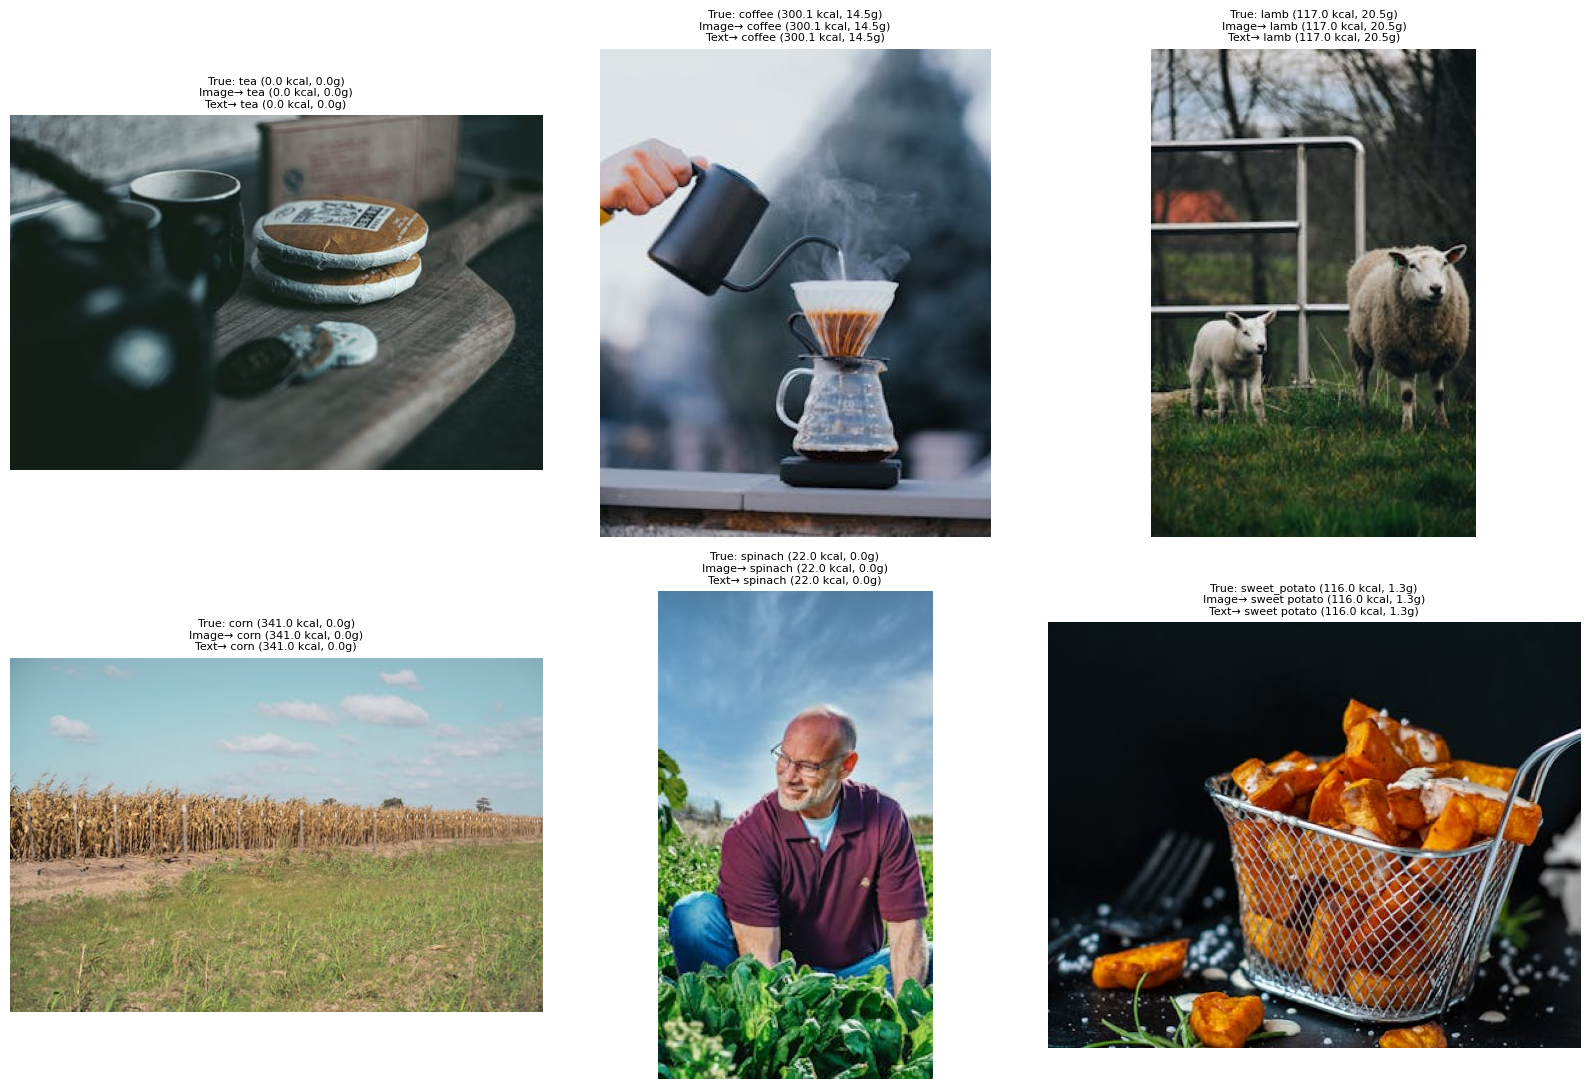

In [40]:
sample_rows = test_df.sample(6, random_state=0)
fig, axes = plt.subplots(2, 3, figsize=(16, 11))

for ax, (_, row) in zip(axes.flat, sample_rows.iterrows()):
    img_pred = predict(image_path=row["image_path"])
    text_pred = predict(question=f"What are the calories and fat in {row['food_name']}?")

    img = Image.open(row["image_path"]).convert("RGB")
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(
        f"True: {row['label']} ({row['calories']} kcal, {row['fat']}g)\n"
        f"Image→ {img_pred['food_name']} ({img_pred['calories']} kcal, {img_pred['fat']}g)\n"
        f"Text→ {text_pred['food_name']} ({text_pred['calories']} kcal, {text_pred['fat']}g)",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

In [41]:
!pip install -q gradio

import gradio as gr

def gradio_predict(image, text):
    if image is None and not text:
        return "Please provide an image, a text description, or both."

    image_path = None
    if image is not None:
        image_path = "/tmp/gradio_upload.jpg"
        image.save(image_path)

    result = predict(image_path=image_path, question=text or None)

    output = f"**Food:** {result['food_name']}\n\n"
    output += f"**Calories:** {result['calories']} kcal (per 100g)\n\n"
    output += f"**Fat:** {result['fat']} g (per 100g)"
    return output


demo = gr.Interface(
    fn=gradio_predict,
    inputs=[
        gr.Image(type="pil", label="Upload a food photo (optional)"),
        gr.Textbox(label="Or describe the food in text (optional)", placeholder="e.g. grilled salmon"),
    ],
    outputs=gr.Markdown(label="Prediction"),
    title="🍽️ Food Calorie & Fat Estimator",
    description="Upload a photo of your food, describe it in text, or both — get an estimate of calories and fat.",
)

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://34aac60f0826551fe3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 12. Notes & Next Steps

- **Compute:** Qwen3-VL-2B + 4-bit LoRA trains comfortably on a single 16 GB GPU (e.g. Colab T4). For higher
  accuracy, try `Qwen/Qwen3-VL-4B-Instruct` or larger, more epochs, or `MAX_PER_CLASS=None` to use the full 18,120-image dataset.
- **Text-only vs image quality:** the text-only path is inherently easier (the food name is given directly in the
  prompt) and should score close to 100% once trained, while the image path depends on real visual recognition. If
  you want the model to lean more on visual grounding, lower `TEXT_ONLY_FRACTION` in Part 5; if you expect most
  real-world queries to be typed food names, raise it.
- **A simpler text-only alternative:** for pure text queries, you could skip the VLM entirely and do fuzzy string
  matching straight against `nutrition_lookup` (no model inference needed) — the fine-tuned text-only path here is
  useful mainly because it shares one model/interface with the image path, and can handle descriptions that aren't
  an exact food name (e.g. "I had a bowl of oatmeal with berries").
- **Portion size:** the nutrition CSV gives values **per 100 g**. If you want *total* calories for a plate, you'd
  need a portion-size estimate too (not in this dataset) — worth flagging in the UI as "per 100g" rather than
  implying an absolute serving size.
- **Grounding:** the `predict()` function already falls back to the lookup table when the model's generated
  numbers are missing — consider always preferring the lookup table's numbers (and using the model purely for
  food *identification*) if you want guaranteed-consistent nutrition numbers.
- **Serving:** once trained, wrap `predict()` in a small FastAPI/Gradio app that accepts an uploaded image, a typed
  question, or both, and returns the JSON `{food_name, calories, fat}`.
